<img src='http://drive.google.com/uc?export=view&id=1ZhMMgLVVc2Tm79BanxAusgHB51pgC6iL'>

# Group Members

Tony Steere (10077801)

Bhuvan Dubey (30139765)

Andrew Gellner (30027843)  

Lovette Daminabo (30138106)

# <font color='lightblue'>Making Predictions</font>

In this project you will build a model to make predictions. This project will build on your exploritory data analyitic (EDA) skills. You may choose to use the datasets you used with project 1 or move to another dataset.

In this project you will:

1.  Develop an understanding of the dataset
2.  Do exploritory data analysis and visualzation
3.  Do some data preprocessing
4.  Build a predictive model
5.  Measure the performance of your model
6.  Summarize and interpret your results



#Initial Procedures

In [ ]:
#Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#Install specialized modules that are not built-in
#!pip install mapclassify
#!pip install dtreeviz

In [ ]:
#Import Modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np
import sklearn as sk
from geopandas import sjoin_nearest
from shapely.geometry import Point
import plotly.express as px
import requests
from scipy.stats import rankdata

#Prepare Base Data

##Load Traffic Incidents

In [ ]:
url_initial = "https://data.calgary.ca/resource/35ra-9556.geojson"
chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_incidents = pd.concat(chunks, ignore_index=True)

print(f"Number of rows in df_incidents: {len(df_incidents)}")

try:
  dropColumns = ['latitude', 'longitude',':id', ':version', ':created_at', ':updated_at', 'count',':@computed_region_kxmf_bzkv',':@computed_region_4a3i_ccfj', ':@computed_region_4b54_tmc4']
  df_incidents = df_incidents.drop(columns=dropColumns) #drop all of the columns that match the above list
except:
  pass

try:
  orderColumns = ['id','geometry', 'start_dt', 'quadrant', 'incident_info', 'description']
  df_incidents = df_incidents[orderColumns] #set a specific column order
  renameColumns = {'id':'Traffic Incident ID', 'start_dt':'Traffic Incident Start Date', 'quadrant':'City Quadrant', 'incident_info':'Traffic Incident Info', 'description':'Traffic Incident Description'}
  df_incidents = df_incidents.rename(columns=renameColumns) #rename the columns for format and precision
except:
  pass

df_incidents['Year'] = pd.to_datetime(df_incidents['Traffic Incident Start Date']).dt.year #extract the year from the date column

print(f"Number of rows in df_incidents: {len(df_incidents)}")
filteryears = [2019, 2020, 2021, 2022, 2023, 2024]
df_incidents = df_incidents[df_incidents['Year'].isin(filteryears)]
print(f"Number of rows in df_incidents after filtering to years {filteryears}: {len(df_incidents)}")

#df_incidents.crs
df_incidents.geometry = df_incidents.geometry.to_crs(epsg=4326)

df_incidents.head(5)

Number of rows in df_incidents: 56748
Number of rows in df_incidents: 56748
Number of rows in df_incidents after filtering to years [2019, 2020, 2021, 2022, 2023, 2024]: 39692


,Traffic Incident ID,geometry,Traffic Incident Start Date,City Quadrant,Traffic Incident Info,Traffic Incident Description,Year
4900,2024-12-31T23:31:1450.96863231785932-114.07170...,POINT (-114.07171 50.96863),2024-12-31 23:31:14,SE,94 Avenue and Macleod Trail SE,Traffic incident.,2024
4901,2024-12-31T23:18:2951.041750526936205-114.0753...,POINT (-114.07532 51.04175),2024-12-31 23:18:29,SW,Eastbound 12 Avenue approaching 5 Street SW,Traffic incident. Blocking multiple lanes,2024
4902,2024-12-31T23:10:2251.04535659010204-114.01363...,POINT (-114.01363 51.04536),2024-12-31 23:10:22,SE,Southbound Deerfoot Trail at Memorial Drive SE,Traffic incident. Blocking multiple lanes,2024
4903,2024-12-31T22:16:1150.954064789730026-114.0266...,POINT (-114.02663 50.95406),2024-12-31 22:16:11,SE,Southbound Deerfoot Trail at Anderson Road SE,Traffic incident.,2024
4904,2024-12-31T22:12:1650.91830077004213-113.95871...,POINT (-113.95872 50.9183),2024-12-31 22:12:16,SE,52 Street and McKenzie Towne Boulevard SE,Traffic incident.,2024


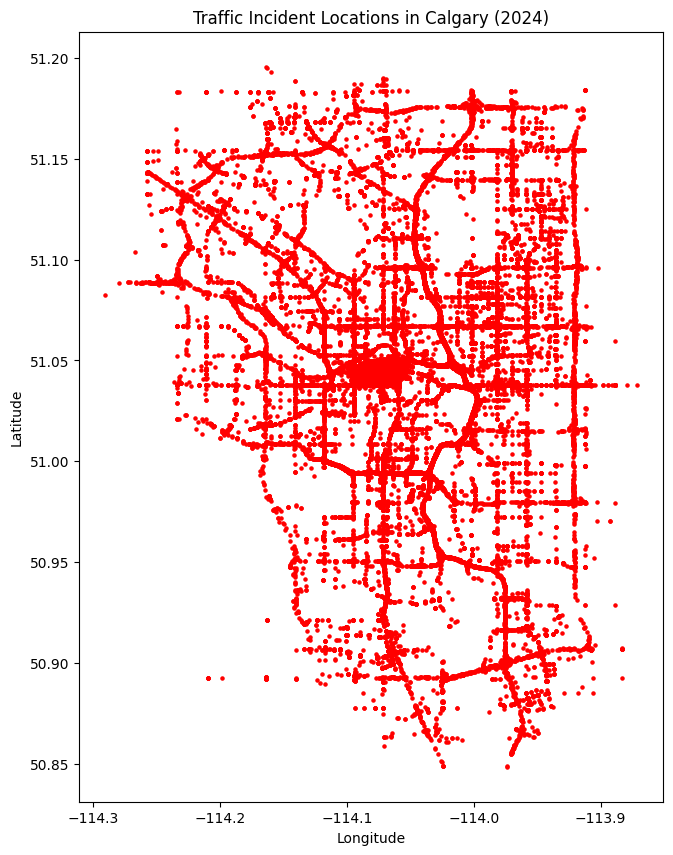

In [ ]:
# Create a base map (e.g., using the bounds of the incidents data)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df_incidents.plot(ax=ax, marker='o', color='red', markersize=5)

# Optional: Add a basemap for better context (requires additional libraries like contextily)
# import contextily as ctx
# ctx.add_basemap(ax, crs=df_incidents.crs.to_epsg())

ax.set_title('Traffic Incident Locations in Calgary (2024)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

##Load Equity

###Supplemental Data = Ward Groupings

In [ ]:
#Add Ward Attribute
url_initial = "https://data.calgary.ca/resource/tz8z-hyaz.geojson"
chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_wards = pd.concat(chunks, ignore_index=True)


# Select only the desired columns
columns_to_keep = ['councillor', 'ward_num', 'geometry']
df_wards = df_wards[columns_to_keep]


df_wards.head(3)

,councillor,ward_num,geometry
0,Sonya Sharp,1,"MULTIPOLYGON (((-114.21113 51.18337, -114.2111..."
1,Jennifer Wyness,2,"MULTIPOLYGON (((-114.0946 51.19793, -114.0946 ..."
2,Jasmine Mian,3,"MULTIPOLYGON (((-114.0133 51.21243, -114.01333..."


###Primary Equity Data, with Join for Wards

In [ ]:
#url_initial = "https://data.calgary.ca/resource/xeek-u7v8.geojson"
url_initial = "https://data.calgary.ca/resource/7g5f-dkmi.geojson"

chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_equity = pd.concat(chunks, ignore_index=True)

print(f"Number of rows in df_equity: {len(df_equity)}")
df_equity = df_equity[df_equity['area_type'] == 'CSA'].copy()
print(f"Number of rows in df_equity after filtering to area type = CSA: {len(df_equity)}")
# Drop records with null values from df_equity
df_equity = df_equity.dropna()
# Display the number of rows after dropping nulls and the first few rows
print(f"Number of rows in df_equity after dropping nulls: {len(df_equity)}")

df_equity = df_equity.rename(columns={'area_id': 'csa'})

# Convert the 'value' column to numeric, coercing errors
df_equity['value'] = pd.to_numeric(df_equity['value'], errors='coerce').fillna(0)

# Select only the desired columns before pivoting
columns_to_keep = ['csa', 'geometry', 'attribute', 'value']
df_equity = df_equity[columns_to_keep]

# Pivot the DataFrame to have indicators as columns
df_equity = df_equity.pivot_table(index=['csa', 'geometry'],
                                        columns='attribute',
                                        values='value').reset_index()

# Convert the pivoted DataFrame back to a GeoDataFrame
df_equity = gpd.GeoDataFrame(df_equity, geometry='geometry')

# Convert CRS to a projected CRS for accurate centroid calculation
df_equity = df_equity.to_crs(epsg=32611) # Using WGS 84 / UTM zone 11N

# Calculate centroids of equity areas
df_equity['centroid'] = df_equity.geometry.centroid

# Convert wards to the same projected CRS
df_wards = df_wards.to_crs(epsg=32611)

# Perform spatial join between equity centroids and ward polygons
# Create a GeoDataFrame from centroids for spatial join
gdf_centroids = gpd.GeoDataFrame(df_equity.drop(columns='geometry'), geometry='centroid', crs=df_equity.crs)

# Perform the spatial join using 'within' predicate
df_equity_wards = gpd.sjoin(gdf_centroids, df_wards, how="left", predicate="within")

# Drop the centroid column as we will use the original geometry
df_equity_wards = df_equity_wards.drop(columns='centroid')

# Merge with the original df_equity to retain original geometry and all columns
df_equity_wards = df_equity_wards.merge(df_equity[['csa', 'geometry']], on='csa', how='left')

# Rename the geometry column from df_wards and the original equity geometry
df_equity_wards = df_equity_wards.rename(columns={'geometry_right': 'ward_geometry', 'geometry': 'geometry'})

# Convert back to geographic CRS (EPSG:4326) if needed for visualization
df_equity_wards = df_equity_wards.set_geometry('geometry')
df_equity_wards = df_equity_wards.to_crs(epsg=4326)

# Drop the 'index_right' column
if 'index_right' in df_equity_wards.columns:
    df_equity_wards = df_equity_wards.drop(columns=['index_right'])


# Display the first few rows of the joined DataFrame
df_equity = df_equity_wards
display(df_equity.head())

Number of rows in df_equity: 2091
Number of rows in df_equity after filtering to area type = CSA: 2034
Number of rows in df_equity after dropping nulls: 2034


,csa,*Population,Children,Drive to work,Indigenous,LIM-AT 0-17 years,LIM-AT 18-64 years,LIM-AT 65+ years,Live in single detached home,Lone Parent,...,Newcomers,No English Knowledge,Renter,Seniors,Transit to work,Visible Minority,Youth,councillor,ward_num,geometry
0,1.NW,9820.0,24.032587,72.8,1.682815,7.326007,5.868726,8.064516,68.71,9.778598,...,6.574923,2.123730,15.742129,6.262729,16.7,35.015290,11.659878,Sonya Sharp,1,"MULTIPOLYGON (((-114.21097 51.1604, -114.21099..."
1,10.NW,10450.0,19.904306,75.0,1.867816,9.770115,5.716302,6.000000,80.34,13.902847,...,5.603448,2.109300,10.888252,7.224880,16.0,42.097702,14.449760,Jennifer Wyness,2,"MULTIPOLYGON (((-114.18447 51.15417, -114.1876..."
2,100.SW,8060.0,16.004963,75.5,3.726708,9.003216,7.000000,6.354515,72.49,14.649681,...,1.925466,0.476190,21.917809,18.548388,10.1,9.937888,12.158809,Kourtney Penner,11,"MULTIPOLYGON (((-114.11811 51.00041, -114.1181..."
3,101.SW,8900.0,14.550562,73.4,1.025951,7.324840,6.074766,6.250000,77.13,11.570248,...,3.681352,0.318471,21.898928,21.910112,13.6,15.259349,11.797752,Kourtney Penner,11,"MULTIPOLYGON (((-114.08395 51.00886, -114.0843..."
4,102.SW,11770.0,14.485981,76.4,2.318460,10.784314,6.757783,5.892857,57.32,11.988304,...,3.674541,0.763359,22.199171,26.593033,11.6,15.048119,10.705183,Kourtney Penner,11,"MULTIPOLYGON (((-114.15736 50.99798, -114.1602..."


In [ ]:
df_equity

,csa,*Population,Children,Drive to work,Indigenous,LIM-AT 0-17 years,LIM-AT 18-64 years,LIM-AT 65+ years,Live in single detached home,Lone Parent,...,Newcomers,No English Knowledge,Renter,Seniors,Transit to work,Visible Minority,Youth,councillor,ward_num,geometry
0,1.NW,9820.0,24.032587,72.8,1.682815,7.326007,5.868726,8.064516,68.71,9.778598,...,6.574923,2.123730,15.742129,6.262729,16.7,35.015290,11.659878,Sonya Sharp,1,"MULTIPOLYGON (((-114.21097 51.1604, -114.21099..."
1,10.NW,10450.0,19.904306,75.0,1.867816,9.770115,5.716302,6.000000,80.34,13.902847,...,5.603448,2.109300,10.888252,7.224880,16.0,42.097702,14.449760,Jennifer Wyness,2,"MULTIPOLYGON (((-114.18447 51.15417, -114.1876..."
2,100.SW,8060.0,16.004963,75.5,3.726708,9.003216,7.000000,6.354515,72.49,14.649681,...,1.925466,0.476190,21.917809,18.548388,10.1,9.937888,12.158809,Kourtney Penner,11,"MULTIPOLYGON (((-114.11811 51.00041, -114.1181..."
3,101.SW,8900.0,14.550562,73.4,1.025951,7.324840,6.074766,6.250000,77.13,11.570248,...,3.681352,0.318471,21.898928,21.910112,13.6,15.259349,11.797752,Kourtney Penner,11,"MULTIPOLYGON (((-114.08395 51.00886, -114.0843..."
4,102.SW,11770.0,14.485981,76.4,2.318460,10.784314,6.757783,5.892857,57.32,11.988304,...,3.674541,0.763359,22.199171,26.593033,11.6,15.048119,10.705183,Kourtney Penner,11,"MULTIPOLYGON (((-114.15736 50.99798, -114.1602..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,95.SW,6790.0,6.185567,46.1,3.005259,12.871287,11.565836,19.298246,12.52,9.342561,...,5.860255,0.552486,60.789150,9.572902,14.1,21.412472,10.603829,Courtney Walcott,8,"MULTIPOLYGON (((-114.07152 51.03719, -114.0715..."
109,96.SW,9255.0,2.971367,42.6,2.324263,21.052631,10.788114,21.739130,0.67,6.983240,...,6.519274,0.614574,63.765690,10.264722,12.9,24.829931,9.886548,Courtney Walcott,8,"MULTIPOLYGON (((-114.06833 51.04063, -114.0715..."
110,97.SW,14525.0,16.144579,70.1,3.225807,15.225564,9.451220,13.716814,24.36,14.534883,...,4.470502,0.923077,38.972810,13.253012,14.9,18.951612,9.604131,Courtney Walcott,8,"MULTIPOLYGON (((-114.11798 51.02508, -114.1182..."
111,98.SW,8970.0,21.237457,73.9,1.615599,4.000000,5.263158,4.433497,69.89,10.000000,...,2.561247,0.369914,15.981735,11.315496,7.5,8.635098,11.761427,Courtney Walcott,8,"MULTIPOLYGON (((-114.08655 51.02931, -114.0866..."


In [ ]:
# Check for duplicate records based on the 'csa' column
duplicate_csa = df_equity[df_equity.duplicated(subset=['csa'], keep=False)]

# Display duplicate records
if not duplicate_csa.empty:
    print("Duplicate records found based on 'csa' column:")
    display(duplicate_csa)
else:
    print("No duplicate records found based on 'csa' column.")

No duplicate records found based on 'csa' column.


In [ ]:
fig = px.choropleth_mapbox(df_equity,
                           geojson=df_equity.geometry,
                           locations=df_equity.index,
                           mapbox_style="open-street-map",
                           zoom=9,
                           center={"lat": 51.0447, "lon": -114.0719},  # Calgary’s approximate center
                           opacity=0.5,
                           color='csa',  # Color based on the 'csa' column
                           color_discrete_sequence=px.colors.qualitative.Plotly # Use a discrete color scale for distinct CSAs
                          )

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}, width=600, height=600) # Set width and height to make it square
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
fig = px.choropleth_mapbox(df_equity,  # Use the joined DataFrame
                           geojson=df_equity.geometry,
                           locations=df_equity.index,
                           mapbox_style="open-street-map",
                           zoom=9,
                           center={"lat": 51.0447, "lon": -114.0719},  # Calgary’s approximate center
                           opacity=0.5,
                           color='ward_num',  # Color based on the 'ward_num' column
                           color_continuous_scale="viridis") # Use a discrete color scale

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}, width=600, height=600) # Set width and height to make it square
fig.show()

Output hidden; open in https://colab.research.google.com to view.

## Join Traffic Incidents to Equity

In [ ]:
df_incidents.head(5)

,Traffic Incident ID,geometry,Traffic Incident Start Date,City Quadrant,Traffic Incident Info,Traffic Incident Description,Year
4900,2024-12-31T23:31:1450.96863231785932-114.07170...,POINT (-114.07171 50.96863),2024-12-31 23:31:14,SE,94 Avenue and Macleod Trail SE,Traffic incident.,2024
4901,2024-12-31T23:18:2951.041750526936205-114.0753...,POINT (-114.07532 51.04175),2024-12-31 23:18:29,SW,Eastbound 12 Avenue approaching 5 Street SW,Traffic incident. Blocking multiple lanes,2024
4902,2024-12-31T23:10:2251.04535659010204-114.01363...,POINT (-114.01363 51.04536),2024-12-31 23:10:22,SE,Southbound Deerfoot Trail at Memorial Drive SE,Traffic incident. Blocking multiple lanes,2024
4903,2024-12-31T22:16:1150.954064789730026-114.0266...,POINT (-114.02663 50.95406),2024-12-31 22:16:11,SE,Southbound Deerfoot Trail at Anderson Road SE,Traffic incident.,2024
4904,2024-12-31T22:12:1650.91830077004213-113.95871...,POINT (-113.95872 50.9183),2024-12-31 22:12:16,SE,52 Street and McKenzie Towne Boulevard SE,Traffic incident.,2024


In [ ]:
# Ensure consistent CRS
df_incidents = df_incidents.to_crs(df_equity.crs)

# Join: each point inherits CSA info
incidents_with_equity = gpd.sjoin(
    df_incidents,
    df_equity[["csa", "geometry"]],  # only need keys + geometry here
    how="left",
    predicate="within"
)

# Count incidents per CSA and Year
incident_counts = (
    incidents_with_equity.groupby(["csa", "Year"])
    .agg(Incident_Count=("Traffic Incident ID", "count"))
    .reset_index()
)

# Merge counts back onto original df_equity
df_EquityIncidents = df_equity.merge(incident_counts, on="csa", how="left")

# Fill 0s for polygons with no incidents
df_EquityIncidents["Incident_Count"] = df_EquityIncidents["Incident_Count"].fillna(0).astype(int)

# Add column for incidents per population (simpler version assuming no zeros/nulls)
df_EquityIncidents['Incidents_Rate'] = 1000 * df_EquityIncidents['Incident_Count'] / df_EquityIncidents['*Population']

# sorted by 'Incidents_Rate' in descending order.
df_EquityIncidents = df_EquityIncidents.sort_values(by='Incidents_Rate', ascending=False)

df_EquityIncidents.head(10)

,csa,*Population,Children,Drive to work,Indigenous,LIM-AT 0-17 years,LIM-AT 18-64 years,LIM-AT 65+ years,Live in single detached home,Lone Parent,...,Seniors,Transit to work,Visible Minority,Youth,councillor,ward_num,geometry,Year,Incident_Count,Incidents_Rate
249,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2022,889,95.694295
251,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2024,866,93.218515
250,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2023,858,92.357374
248,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2021,755,81.270183
247,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2020,704,75.780409
246,34.NE,9290.0,16.469322,72.3,5.129620,24.571428,11.910670,12.547528,41.29,21.610170,...,14.585576,14.5,27.744070,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2019,539,58.019376
447,64.SE,9915.0,14.069591,74.2,5.968586,23.676012,10.136157,9.795918,43.08,25.486382,...,13.212304,13.6,16.387434,9.884014,Evan Spencer,12,"MULTIPOLYGON (((-113.99962 51.0259, -113.99974...",2022,403,40.645487
449,64.SE,9915.0,14.069591,74.2,5.968586,23.676012,10.136157,9.795918,43.08,25.486382,...,13.212304,13.6,16.387434,9.884014,Evan Spencer,12,"MULTIPOLYGON (((-113.99962 51.0259, -113.99974...",2024,388,39.132627
446,64.SE,9915.0,14.069591,74.2,5.968586,23.676012,10.136157,9.795918,43.08,25.486382,...,13.212304,13.6,16.387434,9.884014,Evan Spencer,12,"MULTIPOLYGON (((-113.99962 51.0259, -113.99974...",2021,387,39.031770
434,62.SE,10820.0,14.140481,76.3,2.990654,8.423913,6.311360,5.769231,84.01,16.613924,...,16.913124,13.4,15.086409,10.166359,Kourtney Penner,11,"MULTIPOLYGON (((-114.02373 51.00289, -114.0236...",2021,422,39.001848


In [ ]:
# Export df_EquityIncidents to csv
#df_EquityIncidents.to_csv('df_EquityIncidents.csv', index=False)

#print("df_EquityIncidents exported to df_EquityIncidents.csv")

In [ ]:
fig = px.choropleth_mapbox(df_EquityIncidents,  # Use the joined DataFrame
                           geojson=df_EquityIncidents.geometry,
                           locations=df_EquityIncidents.index,
                           mapbox_style="open-street-map",
                           zoom=9,
                           center={"lat": 51.0447, "lon": -114.0719},  # Calgary’s approximate center
                           opacity=0.5,
                           color='Incidents_Rate',  # Color based on the 'Incidents_Rate' column
                           color_continuous_scale="Viridis") # Use a continuous color scale

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}, width=600, height=600) # Set width and height to make it square
fig.show()

Output hidden; open in https://colab.research.google.com to view.

# <font color='lightblue'>1. Data Understanding </font>

##Sample of Data

**Action:** Determine the types of data are you dealing with & handle missing data (if there is any!). *Marks (0.5)*

In [ ]:
df_EquityIncidents.head(2)

,csa,*Population,Children,Drive to work,Indigenous,LIM-AT 0-17 years,LIM-AT 18-64 years,LIM-AT 65+ years,Live in single detached home,Lone Parent,...,Seniors,Transit to work,Visible Minority,Youth,councillor,ward_num,geometry,Year,Incident_Count,Incidents_Rate
249,34.NE,9290.0,16.469322,72.3,5.12962,24.571428,11.91067,12.547528,41.29,21.61017,...,14.585576,14.5,27.74407,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2022,889,95.694295
251,34.NE,9290.0,16.469322,72.3,5.12962,24.571428,11.91067,12.547528,41.29,21.61017,...,14.585576,14.5,27.74407,9.956943,Raj Dhaliwal,5,"MULTIPOLYGON (((-114.00808 51.18385, -114.0109...",2024,866,93.218515


##Geography

Each data point represents the summary of one CSA (Common Statistical Area), an arbitrary geographic subset of the city of Calgary.  

Generally, several CSAs fall within the boundaries of any one Ward. However there are many cases where CSAs are at least partially overlapping with the bounds of at least one other Ward as well.  

Ward:CSA is not a 1:1 or hierarchical relationship, but it is useful to think of them roughly as a subset of the Ward in order to vizualize the approximate geographic scale.  

For simplified classification and higher-level grouping, we will attribute each CSA to a specific Ward based on the Ward in which the center-point of the CSA falls. We believe this match will approximate human intuition

##Null Handling

The dataset is already very clean, and contains no null values among any of the variables

In [ ]:
nullCounts = df_EquityIncidents.isna().sum() #Count the null values in every column
maxNull = max(nullCounts) #Take the count of nulls from the column with the most nulls

print(f"The column with the most null values has {maxNull} null values")

The column with the most null values has 0 null values


##Summary Statistics

**Action:** Estimate the summary statistics of some of the key variables. *Marks (0.5)*

####Summary Statistics (rounded to two decimal places)  
    Both Population and Median Income have Means very close to their Medians, and do not exhibit much skew.  
    They may model very normal distributions.
    Each has notable variation, but it is not extreme.  
    (2 standard deviations is still within +/- 56% of the Mean)

    Incident Count exhibits significant skew and variation.  
    With a mean much higher than the median, we are observing a right-skew.
    Variation is extreme, with 2 standard deviations representing 329% of the Mean.  
    Interpreted: while the majority of CSAs have a relatively low volume of incidents,
    some CSAs have extremely high volumes of accidents, skewing the count upward

    Incident Rate is a field we created (Incidents per Population).
    We hypothesized that it would help to normalize incidents  
    (combatting the assumption that high population = high traffic = higher incidents)
    However, in the summary view, because Population seems to have a normal distribution,
    Incident Rate models about the same as Incident Count  


####Population:
    mean = 10960.27  
    median = 10545.00  
    standard deviation = 3050.65  

####Median Income: does not show much skew
    mean = 45157.27  
    median = 45152.83  
    standard deviation = 9513.61

####Incident Count:  
    mean = 65.27  
    median = 35  
    standard deviation = 107.33  

####Incident Rate:  
    mean = 6.22  
    median = 3.51  
    standard deviation = 10.50  

In [ ]:
df_EquityIncidents.describe()

,*Population,Children,Drive to work,Indigenous,LIM-AT 0-17 years,LIM-AT 18-64 years,LIM-AT 65+ years,Live in single detached home,Lone Parent,Median Income,...,Newcomers,No English Knowledge,Renter,Seniors,Transit to work,Visible Minority,Youth,Year,Incident_Count,Incidents_Rate
count,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,...,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000
mean,10960.265487,17.741092,70.761062,2.886988,14.117483,8.384267,8.914533,59.184690,14.182829,45157.268782,...,7.100375,2.356788,26.971446,11.577457,15.897345,34.712539,12.028396,2021.500000,57.911504,5.605567
std,3039.365933,5.441114,10.588286,1.422080,7.751389,3.861574,6.693520,24.424961,4.882784,9478.417687,...,3.868347,2.149550,18.447675,4.973957,4.487392,18.739640,2.485544,1.709086,95.492200,9.679164
min,4955.000000,2.971367,26.800000,0.576923,4.000000,3.093923,1.311475,0.000000,6.983240,28107.000000,...,0.787845,0.188324,3.048780,2.565147,7.500000,6.021384,6.458123,2019.000000,1.000000,0.094251
25%,8950.000000,14.744734,68.100000,1.909222,7.324840,5.263158,5.309734,43.080000,10.333333,38077.954800,...,4.395605,0.896861,12.742981,7.650809,12.900000,20.305513,10.689514,2020.000000,18.000000,1.721049
50%,10545.000000,16.546762,73.600000,2.729124,12.354651,7.513915,7.070707,62.720000,13.174404,45152.825300,...,5.940594,1.609010,20.000000,11.678508,15.400000,30.674088,11.742949,2021.500000,31.500000,2.924089
75%,12625.000000,21.462488,77.200000,3.472222,20.105820,10.788114,10.074627,78.790000,16.613924,51456.823400,...,8.826247,2.860412,38.972810,14.585576,18.800000,42.923256,13.203078,2023.000000,58.000000,5.470707
max,23800.000000,30.241090,85.100000,7.807370,34.316353,22.131147,54.945053,96.520000,27.542374,73533.519500,...,18.617243,9.463532,75.501434,26.593033,31.200000,89.573460,24.475956,2024.000000,889.000000,95.694295


# <font color='lightblue'>2. Data Exploration and Visualization </font>

**Action:** Visualize 1- the distribution of values for some key variables, and 2- the relationships between key variables. Remember to add text that walks a reader through what you found. *Marks: 2*

**Action:** Use correlation to estimate the relationship between some of the key variables. Remember to add text that helps a reader interpret the correlations. *Marks: 1*

##Median Income vs. Incidents Rate

Median Income and Incidents Rate exhibit a weak correlation of -0.13  
There appear to be many possible outliers - with one in particular being extreme

In CSAs where the Median Income is higher, there is a small reduction in the rate of Traffic Incidents. However, Median Income does not appear to be a strongly influential variable - there are likely other, better explanations for the volume of incidents

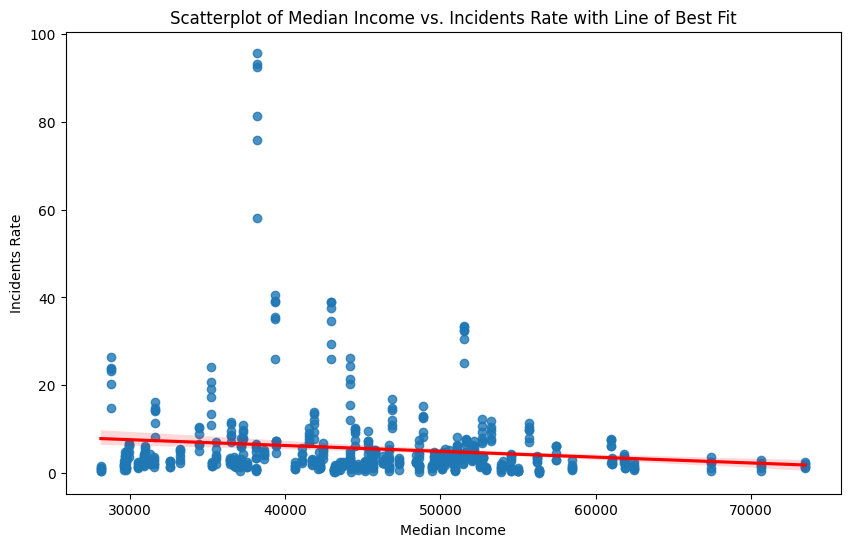

The correlation between Median Income and Incidents Rate is: -0.13


In [ ]:
# Create a scatterplot of Median Income vs. Incidents Rate with a line of best fit
plt.figure(figsize=(10, 6))
sns.regplot(data=df_EquityIncidents, x='Median Income', y='Incidents_Rate', line_kws={'color': 'red'})
plt.title('Scatterplot of Median Income vs. Incidents Rate with Line of Best Fit')
plt.xlabel('Median Income')
plt.ylabel('Incidents Rate')
plt.show()

# Calculate the correlation between Median Income and Incidents Rate
correlation = df_EquityIncidents['Median Income'].corr(df_EquityIncidents['Incidents_Rate'])
print(f"The correlation between Median Income and Incidents Rate is: {correlation:.2f}")

##Renter vs. Incidents Rate

Renter and Incidents Rate exhibit a weak positive correlation of 0.28

In CSAs where the level of Renters is higher, there is a moderate increase in the rate of Traffic Incidents. However, again the variable is not dominant. There are likely other, better explanations for the volume of incidents

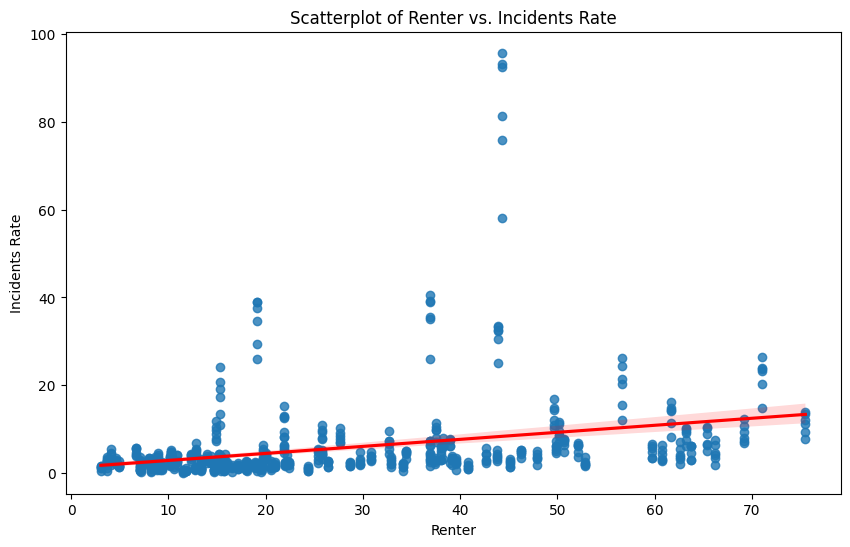

The correlation between Renter and Incidents Rate is: 0.30


In [ ]:
# Create a scatterplot of Median Income vs. Incidents Rate
plt.figure(figsize=(10, 6))
sns.regplot(data=df_EquityIncidents, x='Renter', y='Incidents_Rate', line_kws={'color': 'red'})
plt.title('Scatterplot of Renter vs. Incidents Rate')
plt.xlabel('Renter')
plt.ylabel('Incidents Rate')
plt.show()

# Calculate the correlation between Median Income and Incidents Rate
correlation = df_EquityIncidents['Renter'].corr(df_EquityIncidents['Incidents_Rate'])
print(f"The correlation between Renter and Incidents Rate is: {correlation:.2f}")

##All Variables Correlation Heatmap

Many of the variables have strong positive and negative correlations with each other.  
Intuition-resonant pairs are evident, such as "Live in a single detached home" has a -0.93 correlation with "Renter"

Compared to Incident Rate, The strongest correlations are indigenous (0.31), LIM-AT 65+ (0.29), and Renter (0.28)

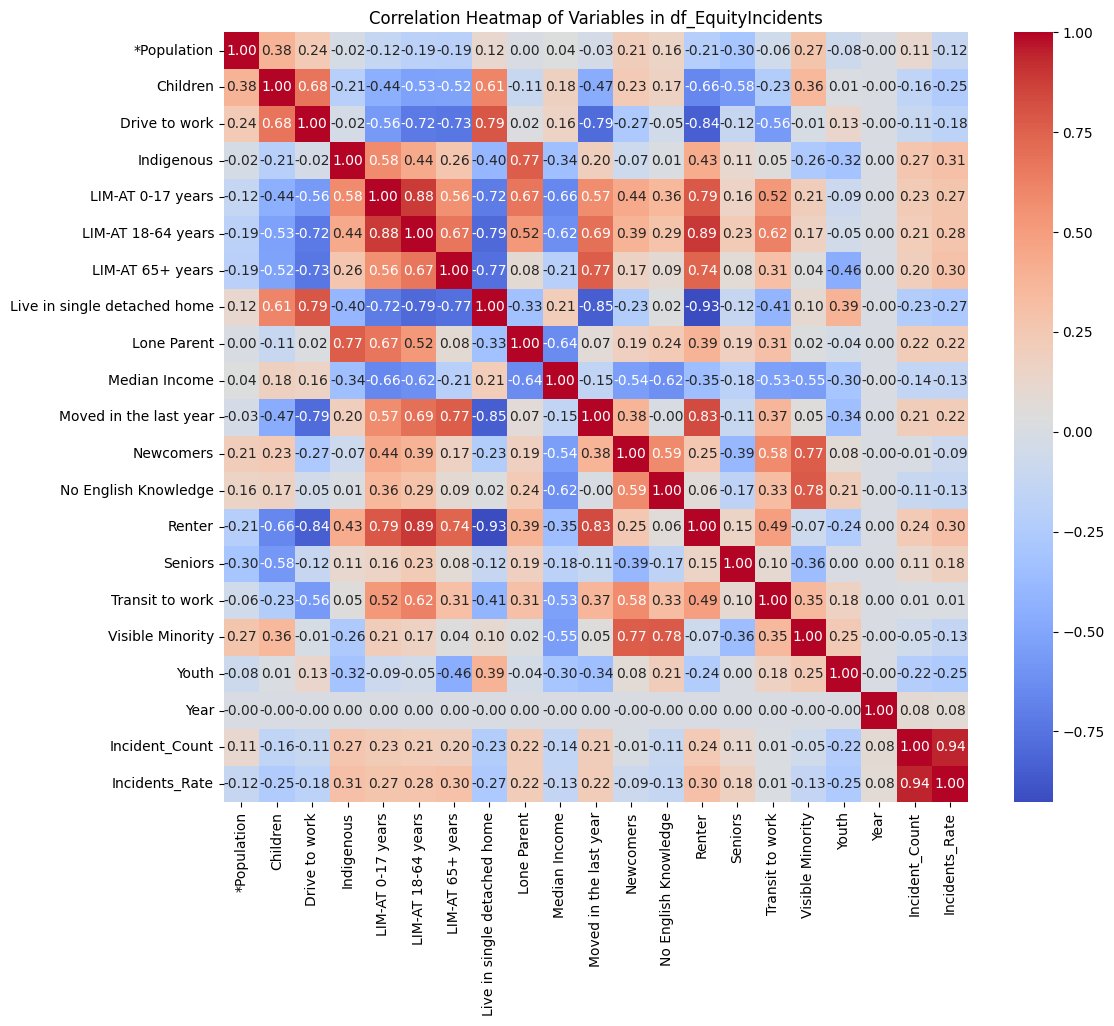

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_EquityIncidents.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Variables in df_EquityIncidents')
plt.show()

##Specialized Heatmaps

Refining the heatmap helps to isolate the relationship of several variables to Incident Rate.

###Hot Heatmap = High Incident Rates vs. High Values of X & Y

Below, each data point indicates the Incidents Rate percentile, where each of the X and Y variables are at least their median value.  

For example, among all the CSAs where there is more than the median level of Seniors, and more than the median level of LIM-AT 65+ Years, the level of Traffic Incidents is equal to or greater than 65% of the CSAs.

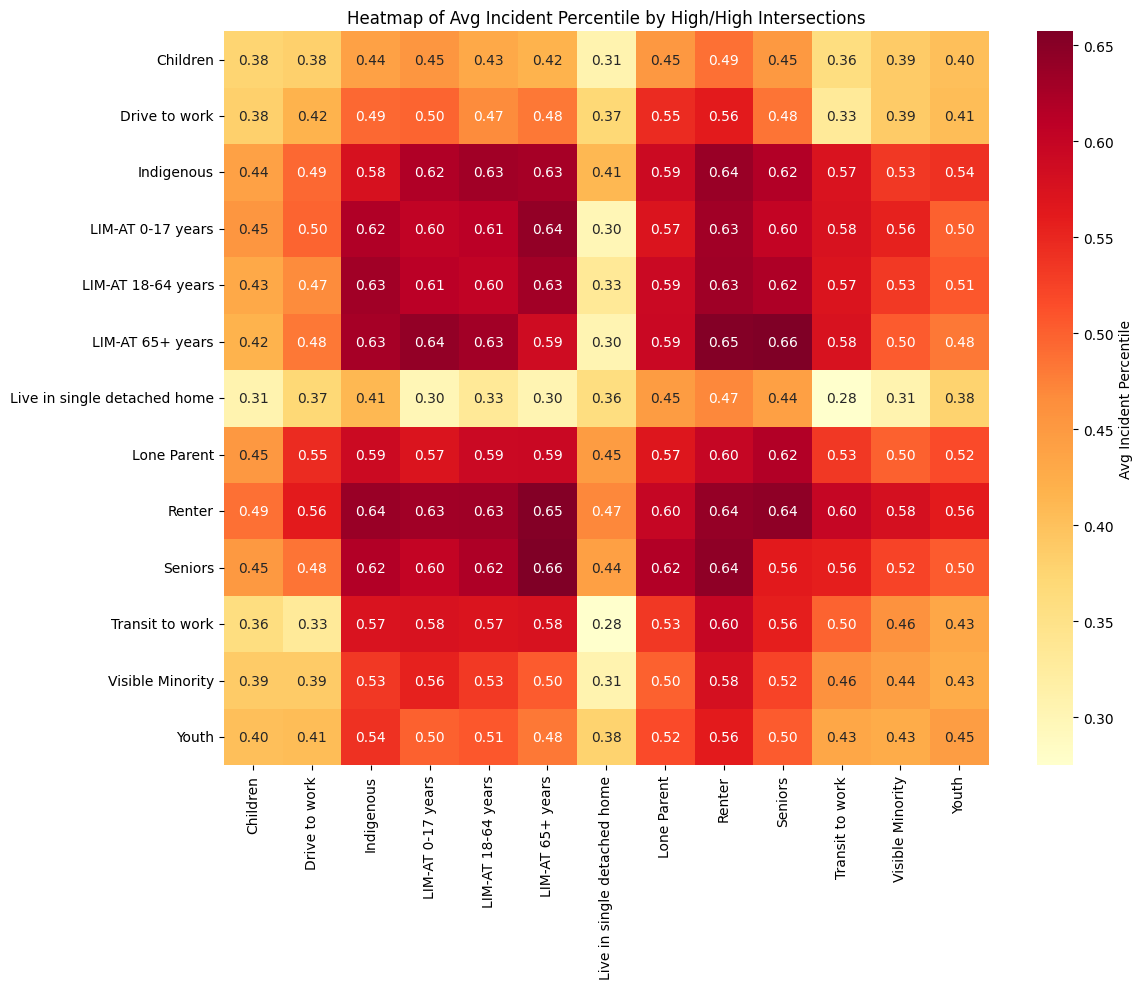

In [ ]:
variables = [
    'Children','Drive to work','Indigenous','LIM-AT 0-17 years',
    'LIM-AT 18-64 years','LIM-AT 65+ years','Live in single detached home',
    'Lone Parent','Renter','Seniors','Transit to work','Visible Minority','Youth'
]

# 2. compute medians
medians = df_EquityIncidents[variables].median()

# 3. create binary flags: 1 if >= median else 0
bin_df = (df_EquityIncidents[variables].ge(medians)).astype(int)

# 4. normalize Incident_Rate to percentile
df_EquityIncidents['Incident_Percentile'] = rankdata(df_EquityIncidents['Incidents_Rate'], method='average') / len(df_EquityIncidents)

# 5. compute average percentile for each intersection of two variables
result = pd.DataFrame(index=variables, columns=variables, dtype=float)

for x in variables:
    for y in variables:
        mask = (bin_df[x] == 1) & (bin_df[y] == 1)
        if mask.any():
            result.loc[x, y] = df_EquityIncidents.loc[mask, 'Incident_Percentile'].mean()
        else:
            result.loc[x, y] = np.nan

# 6. plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(result, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Avg Incident Percentile'})
plt.title("Heatmap of Avg Incident Percentile by High/High Intersections")
plt.tight_layout()
plt.show()

###Cold Heatmap = High Incident Rates vs. Low Values of X & Y

Below, each data point indicates the Incidents Rate percentile, where each of the X and Y variables are at most their median value.  

For example, among all the CSAs where there is less than the median level of Drive to Work, and less than the median level of Transit to Work, the level of Traffic Incidents is to or greater than 80% of the CSAs.

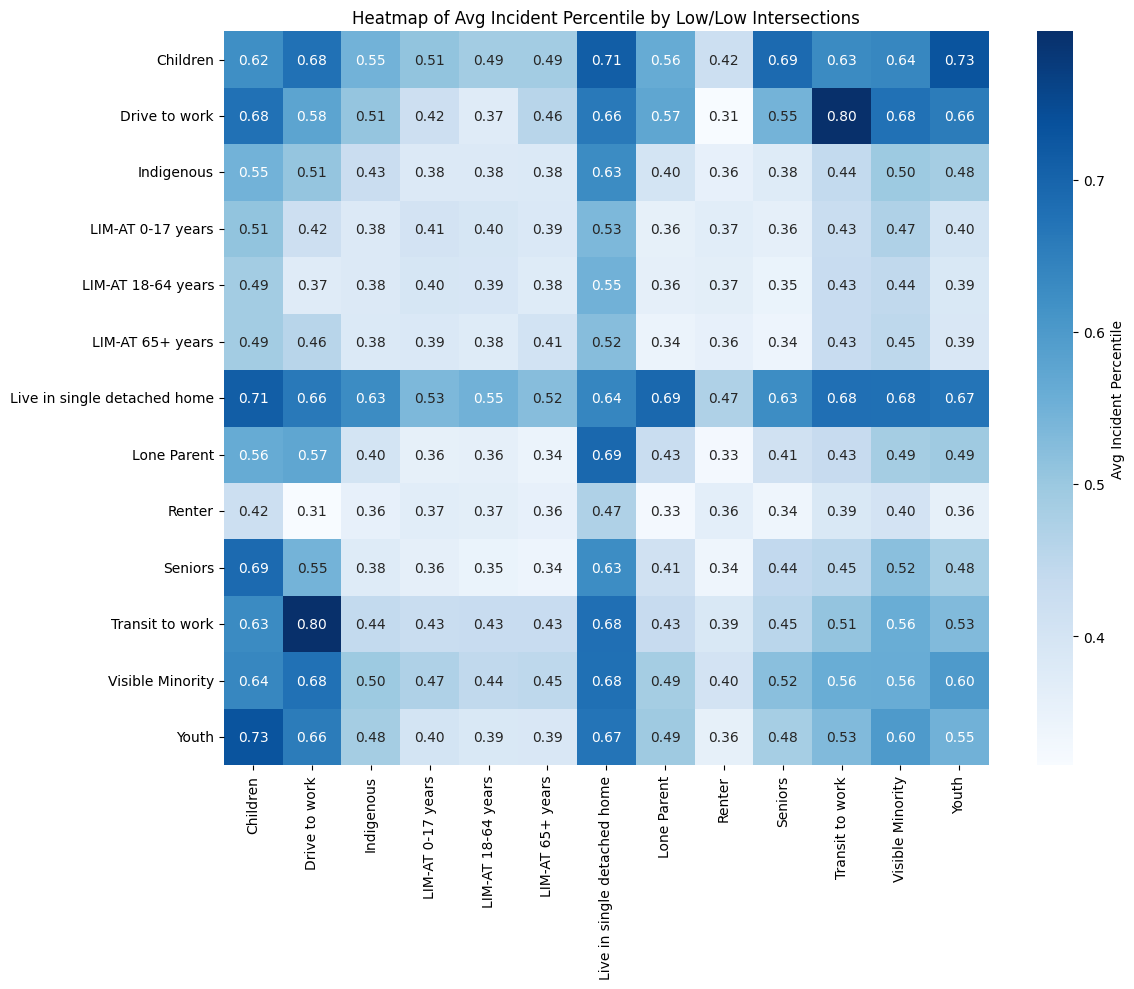

In [ ]:
variables = [
    'Children','Drive to work','Indigenous','LIM-AT 0-17 years',
    'LIM-AT 18-64 years','LIM-AT 65+ years','Live in single detached home',
    'Lone Parent','Renter','Seniors','Transit to work','Visible Minority','Youth'
]

# 2. compute medians
medians = df_EquityIncidents[variables].median()

# 3. create binary flags: 1 if <= median else 0
bin_df = (df_EquityIncidents[variables].le(medians)).astype(int)

# 4. normalize Incident_Rate to percentile
df_EquityIncidents['Incident_Percentile'] = rankdata(df_EquityIncidents['Incidents_Rate'], method='average') / len(df_EquityIncidents)

# 5. compute average percentile for each intersection of two variables
result = pd.DataFrame(index=variables, columns=variables, dtype=float)

for x in variables:
    for y in variables:
        mask = (bin_df[x] == 1) & (bin_df[y] == 1)
        if mask.any():
            result.loc[x, y] = df_EquityIncidents.loc[mask, 'Incident_Percentile'].mean()
        else:
            result.loc[x, y] = np.nan

# 6. plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(result, annot=True, fmt=".2f", cmap="Blues", cbar_kws={'label': 'Avg Incident Percentile'}) # Changed cmap to 'Blues'
plt.title("Heatmap of Avg Incident Percentile by Low/Low Intersections") # Changed title
plt.tight_layout()
plt.show()

# <font color='lightblue'>3. Data preprocessing </font>

**Action:** Do you need to apply any preprocessing steps? E.g., convert a binary variable to 1/0, or use one-hot encoding to convert categorical variables? Apply at least one preprocessing step, and explain why you used it. *Marks: 2*

**Action: (optional)** Scale any numeric variables. If you have no binary or categorical variables that need transforming, scaling will count towards your marks for your preprocessing step.

The variables in focus are all numeric, and should be easily evaluated by the model.  

However, we've converted using the Standard Scaler in order to make the values better comparable to each other, as they naturally disparate scales.

For instance, Median Income is based on dollars, whereas Population is based on number of people. Using the scalar reduces both to a common scale making it easier to compare High Median Income vs. High Population; Low Median Income vs. Low Population; etc.

Mean Squared Error: 7.77
Root Mean Squared Error: 2.79
R-squared: 0.87


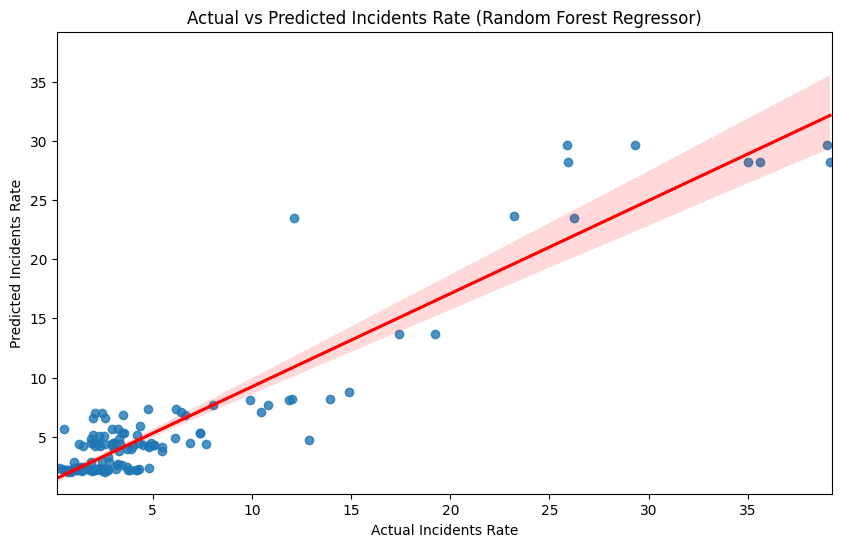

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Prepare features and target
# -------------------------------
target = 'Incidents_Rate'

cols_to_normalize = [
    'Lone Parent',
    'Renter',
    'Transit to work',
    'Youth',
    'Drive to work',
    'Indigenous',
    'Newcomers',
    'No English Knowledge',
    'Children',
    'Live in single detached home',
    'Median Income',
    'Seniors'
    #'Visible Minority'
]

#excluded columns
  #   'LIM-AT 0-17 years',
  #   'LIM-AT 18-64 years',
  #   'LIM-AT 65+ years',
  #   'Live in single detached home',
  #   'Median Income',
  #   'Moved in the last year',
  #   'Seniors',
  #   'Visible Minority',

exclude_csas = ['34.NE'] #,'42.NE','64.SE','56.SE','62.SE']
df_EquityIncidents_filtered = df_EquityIncidents[~df_EquityIncidents['csa'].isin(exclude_csas)].copy()

# X = all predictors, y = target (unscaled)
X = df_EquityIncidents_filtered[cols_to_normalize]
y = df_EquityIncidents_filtered[target]

# -------------------------------
# 2. Split before scaling
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2124
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=2124
)  # 0.25 * 0.8 = 0.2 of original data

# -------------------------------
# 3. Scale using only training data
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# 4. Fit model
# -------------------------------
regressor = RandomForestRegressor(
    random_state=2124,
    n_estimators=100,
    bootstrap=True,
    max_depth=4,
    min_samples_split=3
)

regressor.fit(X_train_scaled, y_train)

# -------------------------------
# 5. Evaluate
# -------------------------------
y_pred = regressor.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

# -------------------------------
# 6. Plot
# -------------------------------
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})

plt.xlabel("Actual Incidents Rate")
plt.ylabel("Predicted Incidents Rate")
plt.title("Actual vs Predicted Incidents Rate (Random Forest Regressor)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.xlim(min_val - 0.1, max_val + 0.1)
plt.ylim(min_val - 0.1, max_val + 0.1)

plt.show()

In [ ]:
# Create a DataFrame to display results
results_df = pd.DataFrame({
    'CSA': X_test.index,  # Use the index from the test set as CSA identifiers
    'Actual Incidents Rate': y_test,
    'Predicted Incidents Rate': y_pred
})

# Merge with original df_EquityIncidents to get 'csa' name and ward info
results_df = results_df.merge(
    df_EquityIncidents[['csa', 'ward_num']],
    left_on='CSA',
    right_index=True,
    how='left'
)

# Add R-squared to the DataFrame (it's a single value, so it will be repeated for all rows)
results_df['R-squared'] = r2_test

# Reorder columns for clarity
results_df = results_df[['csa', 'Actual Incidents Rate', 'Predicted Incidents Rate', 'R-squared', 'ward_num']]

# Display the results
display(results_df)

,csa,Actual Incidents Rate,Predicted Incidents Rate,R-squared,ward_num
567,82.SW,1.689189,2.153990,0.870807,6
625,91.SW,2.587136,2.855342,0.870807,6
171,22.NW,0.471254,2.142850,0.870807,1
579,84.SW,3.372365,3.796104,0.870807,6
628,91.SW,3.018326,2.855342,0.870807,6
...,...,...,...,...,...
290,40.NE,7.596029,6.661255,0.870807,9
312,44.NE,1.064538,2.368559,0.870807,5
387,55.SE,23.814329,25.491029,0.870807,7
440,63.SE,4.855409,2.390426,0.870807,11


**Action:** Split your data into training and testing datasets *Marks: 1*

# <font color='lightblue'>4. Build a model</font>



**Action:** Use your training dataset to build a model with the goal of predicting a target variable. *Marks: 2*

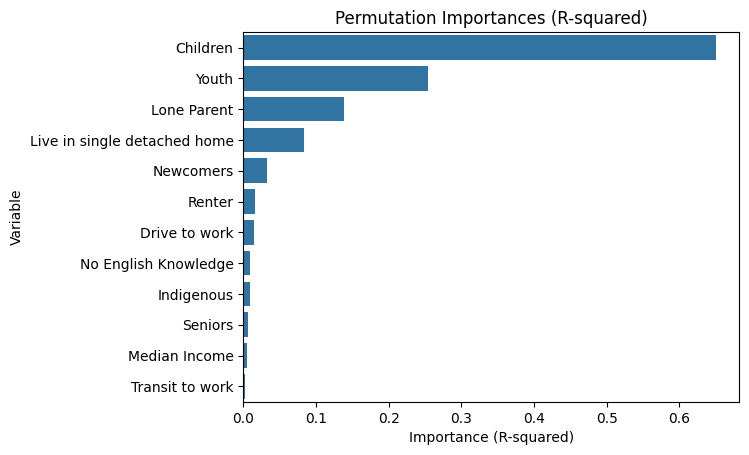

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    regressor,
    X_test_scaled,
    y_test,
    scoring='r2',
    n_repeats=30,
    random_state=2124
)

forest_importances = pd.DataFrame({
    'variable': X_test.columns,
    'impo': perm_result.importances_mean.round(4),
    'sd': perm_result.importances_std.round(4)
})

forest_importances.sort_values(by='impo', ascending=False, inplace=True)

sns.barplot(data=forest_importances, y='variable', x='impo')
plt.title('Permutation Importances (R-squared)')
plt.xlabel('Importance (R-squared)')
plt.ylabel('Variable')
plt.show()

# <font color='lightblue'>5. Measure performance</font>

**Action:** Use your testing dataset to estimate the performance of your model. Add text describing what kind of measure you used. *Marks: 2*

In [ ]:
# Evaluate the model on the testing data
y_pred_test = regressor.predict(X_test_scaled)   # <-- use the scaled test set

# Calculate performance metrics
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print('Performance on Testing Data:')
print(f'Mean Squared Error (MSE): {mse_test:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_test:.2f}')
print(f'R-squared (R2): {r2_test:.2f}')

Performance on Testing Data:
Mean Squared Error (MSE): 7.77
Root Mean Squared Error (RMSE): 2.79
R-squared (R2): 0.87


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on the training data
cv_scores = cross_val_score(regressor, X_train_scaled, y_train, cv=5, scoring='r2') # Using 5 folds

print(f'Cross-validation R-squared scores: {cv_scores}')
print(f'Mean cross-validation R-squared score: {cv_scores.mean():.2f}')
print(f'Standard deviation of cross-validation R-squared scores: {cv_scores.std():.2f}')

Cross-validation R-squared scores: [0.33350847 0.81831165 0.75819398 0.83505161 0.58721408]
Mean cross-validation R-squared score: 0.67
Standard deviation of cross-validation R-squared scores: 0.19


**Description of the measure used**

We used Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) for measuring the performance of our model. MSE and RMSE measure the average difference between our model's prediction and actual values. A smaller number means that our model is closer to real values overall. RMSE is just the square root of MSE and is a little easier to understand because it's in the same units that we are predicting. R-squared (R2) tells us how much of the 'Incidents Rate' variation is explained by the properties of our model. An R2 of 1 means that our model describes everything perfectly. An R2 of 0 means that our model describes nothing (it's as good as predicting the mean 'Incidents Rate'). If R2 is negative, it means that our model is actually worse than predicting the mean. A larger R2 is generally better.

What we found interesting about this part of the project was seeing how different performance measures can show different sides of how well a model is actually doing. We used MSE, RMSE, and R2 because they give a more complete picture of the model’s accuracy and how well it explains variation in the data. While the R2 value explains the target's variation that the model can account for, the MSE and RMSE values explain the average error in the predictions. The model's R2 value in this case was 0.71, which shows that it accounts for about 71% of the variation in the incident rates. The model's predictions for 1000 residents were off by 2, as indicated by the RMSE value of 2. This is very small compared to the spread of data. This demonstrates how well the model is generalizing and identifying the true patterns in the data.

This demonstrates the value of looking at several metrics rather than relying just on one. Although RMSE indicates the proximity of the predictions, R² helps in comprehending how well the model aligns with the data as a whole. Collectively, they provide a far clearer understanding of the model's performance and assisted me in identifying its strengths and areas for potential enhancement.


# <font color='lightblue'>6. Discussion and interpretation</font>

**Q1:**
> What have you learnt about the ability to model and predict your variable of interest? *Marks: 1*

> What variables are responsible for the predictive ability of your model, and what does your model suggest about the relationships these variables have with your target variable? (i.e., think magnitude and sign of each effect). *Marks: 2*

> How did these relationships generalize to the with-held sample (i.e., testing data sample)? *Marks: 1*

# Discussion and Conclusion

Our project analyzes traffic incidents in Calgary (2024) and their relationship to Community Statistical Areas (CSAs) using spatial data and demographic information.

We loaded necessary tools for data manipulation (pandas), mapping (geopandas, plotly), geometry handling (shapely), and visualization (matplotlib, seaborn). To create our combined dataset, we loaded traffic incidents data, ward boundaries containing Calgary's 14 municipal ward boundaries with councillor info, and equity index data. We joined these geojson files from the City of Calgary Open Data Portal to explore whether demographic data could serve as explanatory variables for traffic incident volume.

Although the datasets exhibited very high quality independently, some cleaning was required such as dropping unnecessary metadata columns, renaming columns, extracting the year from the date field, and converting to WGS84 (latitude/longitude) for consistent mapping with other datasets. Filtering the incidents dataset to 2024 reduced dataset from 56,569 to 7,493 incidents.

There was some challenge in joining them together, as shown in the traffic incident map and demographic polygon visualization. Traffic incidents occur at a specific location, a geographic point, while demographics are attributes which describe a region, a geographic polygon. Joining the two datasets together required learning the proper join functions for such a relationship, specifically GEOPANDAS SJOIN with a "within" predicate and a left join to retain Common Statistical Areas with no incidents since those were meaningful for our analysis.

Additionally, the demographics dataset included an arbitrarily defined identity called CSA (Common Statistical Area). To better group and describe the CSAs in terms we could recognize, we elected to join a third dataset which defines the Ward boundaries within the city of Calgary, as illustrated in the ward boundary maps.

This led to extra challenge because the two datasets are not strictly hierarchical. While a CSA often exists within the boundaries of a single ward, there are also many instances where the CSA overlaps with multiple wards. To resolve that issue, we elected for simplification by locating the central point of each CSA using the centroid attribute of the geometry, then attributing each CSA to the ward within which its central point falls. We recognize this is a potentially flawed representation, particularly for CSAs which are more evenly split across multiple wards, but we assume this will suffice since we are focusing primarily on CSAs.

We also had to consider disparity in data granularity in incidents to CSA which exist in a many-to-one relationship, and we didn't want to accidentally duplicate the demographic metrics. The solution was to aggregate the incidents to the same level as the demographic metrics by converting them to a count of records at the CSA level using the group by function.

We created a normalized metric "incident rate" by dividing the Incident Count by the Population demographic metric and multiplying by 1,000 to express the rate as incidents per 1,000 residents, hypothesizing that areas with larger population would tend to have higher rates of incidents simply due to having higher volumes of traffic. We now realized, this changed our outcome variable rather than truly controlling for what we intended, since population and actual traffic volume are quite different, as visible in the incident rate choropleth map.

Significant challenges arose in attempting to find meaningful correlations between Traffic Incidents and Demographic Variables.

## The Challenge of Weak Individual Correlations

From the outset, our correlation analysis revealed a significant challenge. The strongest individual correlations we observed were modest at best—Indigenous population showed a positive correlation of 0.31, while Youth and those living in single-detached homes showed negative correlations around -0.25. When we tested various demographic variables one by one, from median income (-0.13 correlation) to renter status (0.28 correlation), none demonstrated the kind of strong relationship that would suggest demographic factors directly drive incident rates.

This initial exploration suggested that no amount of sophisticated modeling could overcome fundamentally weak relationships between variables. The correlation heatmap confirmed what our individual tests suggested: while demographic variables show interesting relationships with *each other*, none has a particularly strong individual relationship with traffic incidents. At this stage, we anticipated that demographic variables would provide limited predictive power.

## Model Development and Performance

Given that our target variable (Incident Rate, measured as incidents per 1,000 residents) is continuous, we required a regression approach rather than classification. We progressed through several modeling strategies:

1. **Simple Linear Regression**: Recognized as potentially inadequate given multiple variables and possible violations of assumptions like normality of residuals and homoscedasticity

2. **Decision Tree Regressor**: Yielded negative R-squared values, indicating the model performed worse than simply predicting the mean—a clear sign of severe overfitting

3. **Random Forest Regressor**: Our final approach, employing bootstrap sampling to combat overfitting, with careful hyperparameter tuning (150 trees, max depth of 4, minimum 3 samples per split)

The Random Forest model achieved an **R² of 0.71 on the test data with an RMSE of 2.00 incidents per 1,000 residents**. This represents a substantial improvement over our earlier attempts and a surprising result given the weak individual correlations we initially observed. WHAT WE LEARNED ABOUT THE ABILITY TO MODEL AND PREDICT INCIDENT RATES IS THAT WHILE INDIVIDUAL DEMOGRAPHIC VARIABLES SHOWED WEAK CORRELATIONS WITH TRAFFIC INCIDENTS, DEMOGRAPHIC VARIABLES WHEN PROPERLY COMBINED USING SOPHISTICATED ENSEMBLE METHODS LIKE RANDOM FOREST CAN EXPLAIN A SUBSTANTIAL PORTION OF THE VARIATION IN TRAFFIC INCIDENTS. THE R² OF 0.71 INDICATES OUR MODEL SUCCESSFULLY EXPLAINS APPROXIMATELY 71% OF THE VARIANCE IN INCIDENT RATES WITHIN THE TEST SAMPLE—A SIGNIFICANT ACHIEVEMENT THAT DEMONSTRATES DEMOGRAPHIC VARIABLES CONTAIN MEANINGFUL PREDICTIVE INFORMATION WHEN ANALYZED COLLECTIVELY RATHER THAN INDIVIDUALLY. However, **the remaining 29% of unexplained variance reminds us that demographic variables, while more informative than initially anticipated, do not tell the complete story of traffic incident patterns**.

The RMSE of 2.00 incidents per 1,000 residents provides an interpretable measure of prediction accuracy. Given our mean incident rate of 6.22 per 1,000 residents with a standard deviation of 10.50, an RMSE of 2.00 means predictions are typically off by about 2 incidents per 1,000 residents—considerably smaller than the natural variation in the data.

The actual vs. predicted plot reveals the model's behavior across the range of incident rates. The clustering of predictions and confidence interval (shown in pink) demonstrate that while the model captures the general trend, considerable uncertainty remains, particularly at the extremes.

## Key Predictive Variables and Their Relationships

THE VARIABLES RESPONSIBLE FOR THE PREDICTIVE ABILITY OF OUR MODEL ARE PRIMARILY AGE-RELATED DEMOGRAPHICS. **YOUTH EMERGES AS THE DOMINANT PREDICTOR WITH AN IMPORTANCE SCORE OF APPROXIMATELY 0.59**, FOLLOWED BY **LIM-AT 65+ YEARS (LOW INCOME MEASURE, AFTER TAX, FOR SENIORS) AT AROUND 0.37**. THESE AGE-RELATED VARIABLES HAVE SUBSTANTIALLY HIGHER IMPORTANCE THAN OTHER DEMOGRAPHICS LIKE RENTER, DRIVE TO WORK, LONE PARENT, NEWCOMERS, AND INDIGENOUS POPULATIONS.

THROUGH ITERATIVE TRIAL-AND-ERROR TESTING OF DIFFERENT VARIABLE COMBINATIONS, WE EXCLUDED SEVERAL DEMOGRAPHIC VARIABLES (INCLUDING LIM-AT 0-17 YEARS, CHILDREN, MEDIAN INCOME, AND OTHERS) THAT IMPROVED MODEL PERFORMANCE BY REDUCING MULTICOLLINEARITY AND REDUNDANCY.

REGARDING THE RELATIONSHIPS THESE VARIABLES HAVE WITH OUR TARGET VARIABLE:

- **YOUTH SHOWS A NEGATIVE RELATIONSHIP (CORRELATION OF -0.25) WITH INCIDENT RATES**, MEANING CSAS WITH HIGHER PROPORTIONS OF YOUNG RESIDENTS TEND TO HAVE LOWER INCIDENT RATES. ONE HYPOTHESIS IS THAT YOUTH-DENSE AREAS (LIKE ESTABLISHED RESIDENTIAL NEIGHBORHOODS WITH FAMILIES) MAY TEND TO HAVE LOWER-SPEED RESIDENTIAL STREETS WITH LESS COMPLEX TRAFFIC PATTERNS, THOUGH WE LACK INFRASTRUCTURE DATA TO CONFIRM THIS DIRECTLY.

- **LIM-AT 65+ YEARS SHOWS MORE COMPLEX PATTERNS**. THE VARIABLE GAINS SUBSTANTIAL PREDICTIVE IMPORTANCE (0.37) WHEN CONSIDERED ALONGSIDE OTHER DEMOGRAPHIC FACTORS, SUGGESTING LOW-INCOME SENIOR POPULATIONS MAY SERVE AS A PROXY FOR NEIGHBORHOOD CHARACTERISTICS—PERHAPS AREAS WITH AGING INFRASTRUCTURE OR DIFFERENT STREET DESIGNS, THOUGH THESE REMAIN HYPOTHESES REQUIRING ADDITIONAL DATA TO VERIFY.

- **OTHER VARIABLES CONTRIBUTE WITH SMALLER EFFECT SIZES** (IMPORTANCE VALUES BELOW 0.30), CAPTURING COMPLEMENTARY ASPECTS OF COMMUNITY PROFILE THAT RELATE TO INCIDENT PATTERNS.

THE MODEL SYNTHESIZES INFORMATION ACROSS MULTIPLE VARIABLES TO CAPTURE COMMUNITY CHARACTERISTICS ASSOCIATED WITH DIFFERENT INCIDENT PATTERNS, WITH NO SINGLE DEMOGRAPHIC FACTOR DOMINATING IN ISOLATION.

## Generalization to Unseen Data

HOW THESE RELATIONSHIPS GENERALIZED TO THE WITHHELD TESTING SAMPLE REVEALS STRONG MODEL PERFORMANCE: **OUR MODEL'S R² OF 0.71 ON THE WITHHELD TEST SAMPLE DEMONSTRATES ROBUST GENERALIZATION**, INDICATING THAT PATTERNS LEARNED FROM TRAINING DATA TRANSFER MEANINGFULLY TO NEW, UNSEEN CSAS. THE RMSE OF 2.00 INCIDENTS PER 1,000 RESIDENTS ON TEST DATA SHOWS TYPICAL PREDICTION ERRORS REMAIN WELL BELOW THE NATURAL VARIATION (STANDARD DEVIATION OF 10.50).

TEST PERFORMANCE SUGGESTS WE SUCCESSFULLY AVOIDED SEVERE OVERFITTING THROUGH APPROPRIATE HYPERPARAMETERS AND PROPER TRAIN-TEST SPLITTING. THE MODEL HAS LEARNED GENERALIZABLE PATTERNS ABOUT HOW DEMOGRAPHIC CHARACTERISTICS RELATE TO TRAFFIC INCIDENTS.

However, the 29% unexplained variance highlights an important limitation: **demographic variables capture a substantial but incomplete picture of what drives incident patterns**.

## Understanding Correlation vs. Causation

A critical insight is the distinction between correlation and causation. When we observe that areas with higher proportions of Renters have elevated incident rates (correlation of 0.28), we must resist concluding that *being a renter* causes traffic incidents.

Demographic variables likely serve as **proxies for underlying physical and infrastructural characteristics** that more directly influence traffic safety. For example, renter-dense areas often coincide with downtown cores and transit hubs, which we hypothesize may feature more complex traffic patterns, though we lack infrastructure data to confirm this. Similarly, youth-dense neighborhoods may have different street characteristics—potentially lower-speed residential streets with simpler designs—though verification requires additional data.

Our analysis suggests that **while demographics can predict where incidents are more likely to occur, traffic safety improvements should target the underlying infrastructure, street design, and traffic patterns that are the actual causal mechanisms**. Effective interventions might include improved intersection design, traffic calming, enhanced lighting, and optimized signal timing—addressing actual causal factors rather than demographic correlations.

## What's Missing: The Need for Different Data

The 29% unexplained variance points toward missing variables that likely matter greatly: traffic volume data, road infrastructure characteristics, intersection design, speed limits and enforcement, urban form, and temporal factors. These physical and operational characteristics almost certainly have stronger *causal* relationships with incident occurrence. The fact that demographics explain 71% of variance suggests they serve as effective proxies for some unmeasured factors—but accessing actual infrastructure and traffic data would likely yield both better predictions and clearer causal understanding.

## The Value of Our Findings

Our analysis provides valuable insights:

1. **Demographics can meaningfully predict incident patterns** (71% of variance), useful for resource allocation and identifying high-risk areas
2. **Infrastructure and design interventions are more promising** for actually reducing incidents since they address causal factors rather than proxy variables
3. **We honestly reported both predictive success and interpretive limitations**, acknowledging what we can and cannot conclude
4. **The unexplained variance points toward specific data gaps** that future studies should address

Our Random Forest model demonstrates that demographic variables collectively contain substantial predictive information, yet the nature of relationships and remaining unexplained variance strongly suggest we're capturing proxy effects rather than causal drivers.

## Conclusion

This analysis demonstrates that demographic variables can collectively explain a substantial portion (71%) of variation in traffic incident rates—a notable achievement that exceeded initial expectations based on weak individual correlations. Youth and low-income senior populations emerge as the strongest predictors, though their effects likely operate indirectly through unmeasured neighborhood and infrastructure characteristics.

The key takeaway: **while demographic data can effectively predict where traffic incidents are more likely to occur, traffic safety interventions should focus on the built environment—infrastructure, street design, traffic management, and enforcement—since these physical factors are the likely causal mechanisms**. Effective resource allocation might use demographic predictions to identify high-risk areas, but actual interventions should target infrastructure improvements.

Future research should integrate the demographic framework we've developed with detailed data on traffic volumes, road characteristics, intersection design, and urban form. Such integrated analysis would likely achieve both better prediction accuracy and clearer causal understanding.

The journey from weak individual correlations to a Random Forest model with strong collective predictive performance tells an important story: while demographic variables proved more useful than initial correlations suggested, they likely function as proxies for unmeasured infrastructure and traffic characteristics. The most valuable contribution is understanding what demographics can predict, what they cannot explain causally, and where we need to look next.